In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Load your CSV file
df = pd.read_csv("crop_yield.csv")  # Replace with your actual file name
print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  


In [8]:
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Drop rows with missing values (or fill them using fillna if needed)
df = df.dropna()
print("\nDataset after handling missing values:", df.shape)


Missing values:
 Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

Dataset after handling missing values: (19689, 10)


In [9]:
# Encode categorical features using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [21]:
# Assuming you calculated Yield before this
X = df.drop(columns=["Yield"])  # Drop target column from features
y = df["Yield"]

In [22]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
 #Identify categorical and numerical columns
categorical_cols = ['Crop', 'Season', 'State']
numerical_cols = ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

# Define target variable (Yield)
target = 'Yield'

In [34]:
# Define X (features) and y (target)
X = df.drop(columns=[target])
y = df[target]

# Split into train & test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (15751, 9)
Testing Data Shape: (3938, 9)


In [35]:
# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train your model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# Now save the model
import joblib
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [25]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# Save XGBoost model
joblib.dump(xgb_model, 'xgboost_model.pkl')

['xgboost_model.pkl']

In [26]:
model.fit(X_train, y_train)
joblib.dump(model, "best_model.pkl")

['best_model.pkl']

In [27]:
def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    
    # Training predictions
    y_train_pred = model.predict(X_train)
    # Testing predictions
    y_test_pred = model.predict(X_test)
    
    # Training metrics
    print(f"\n{model_name} - Training Metrics:")
    print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
    print(f"R² Score: {r2_score(y_train, y_train_pred):.2f}")
    
    # Testing metrics
    print(f"\n{model_name} - Testing Metrics:")
    print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
    print(f"R² Score: {r2_score(y_test, y_test_pred):.2f}")

In [28]:
# 1. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
evaluate_model(rf, "Random Forest")

# 2. XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, objective='reg:squarederror', random_state=42)
evaluate_model(xgb, "XGBoost")


Random Forest - Training Metrics:
MAE: 4.01
RMSE: 69.29
R² Score: 0.99

Random Forest - Testing Metrics:
MAE: 11.25
RMSE: 273.32
R² Score: 0.91

XGBoost - Training Metrics:
MAE: 1.32
RMSE: 7.09
R² Score: 1.00

XGBoost - Testing Metrics:
MAE: 14.96
RMSE: 317.79
R² Score: 0.87


In [29]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search for Random Forest
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# Best parameters and evaluation
best_rf = grid_rf.best_estimator_
print("Best RF Parameters:", grid_rf.best_params_)
evaluate_model(best_rf, "Random Forest (Tuned)")

Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest (Tuned) - Training Metrics:
MAE: 4.01
RMSE: 69.29
R² Score: 0.99

Random Forest (Tuned) - Testing Metrics:
MAE: 11.25
RMSE: 273.32
R² Score: 0.91


In [30]:
# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid search for XGBoost
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=3, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# Best parameters and evaluation
best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Parameters:", grid_xgb.best_params_)
evaluate_model(best_xgb, "XGBoost (Tuned)")

Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

XGBoost (Tuned) - Training Metrics:
MAE: 2.89
RMSE: 21.00
R² Score: 1.00

XGBoost (Tuned) - Testing Metrics:
MAE: 14.65
RMSE: 246.79
R² Score: 0.92


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def print_metrics(model_name, y_train, y_pred_train, y_test, y_pred_test):
    print(f"\n{model_name} - Training Evaluation:")
    print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
    print(f"R² Score: {r2_score(y_train, y_pred_train)}")

    print(f"\n{model_name} - Testing Evaluation:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_test)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test))}")
    print(f"R² Score: {r2_score(y_test, y_pred_test)}")

In [33]:
# Evaluate Random Forest
y_pred_train_rf = best_rf.predict(X_train)
y_pred_test_rf = best_rf.predict(X_test)
print_metrics("Random Forest", y_train, y_pred_train_rf, y_test, y_pred_test_rf)

# Evaluate XGBoost
y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_test_xgb = best_xgb.predict(X_test)
print_metrics("XGBoost", y_train, y_pred_train_xgb, y_test, y_pred_test_xgb)


Random Forest - Training Evaluation:
MAE: 400372.35868611524
RMSE: 7979760.720817505
R² Score: 0.9990564758159085

Random Forest - Testing Evaluation:
MAE: 1077467.1871762318
RMSE: 20304080.4021086
R² Score: 0.9945773188515771

XGBoost - Training Evaluation:
MAE: 207554.359375
RMSE: 943043.9242537963
R² Score: 0.9999868273735046

XGBoost - Testing Evaluation:
MAE: 1801828.875
RMSE: 28628755.758950893
R² Score: 0.9892191886901855


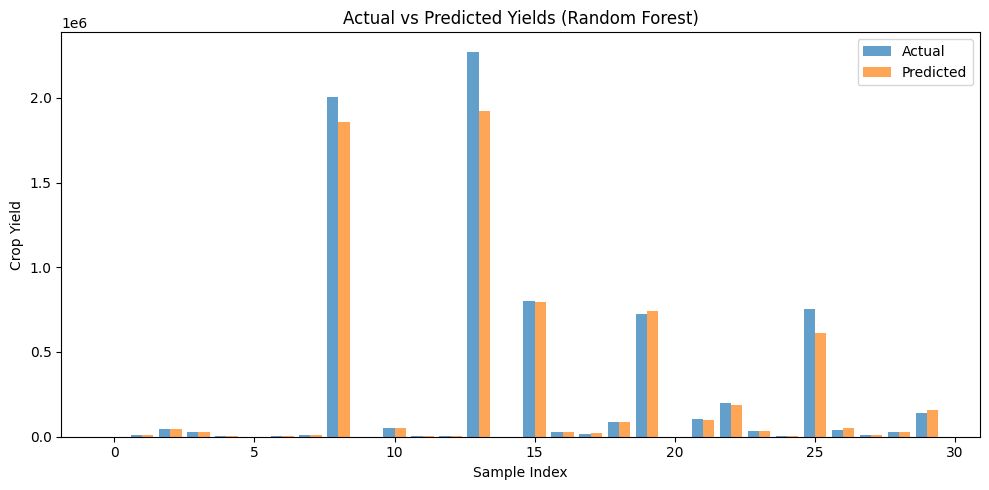

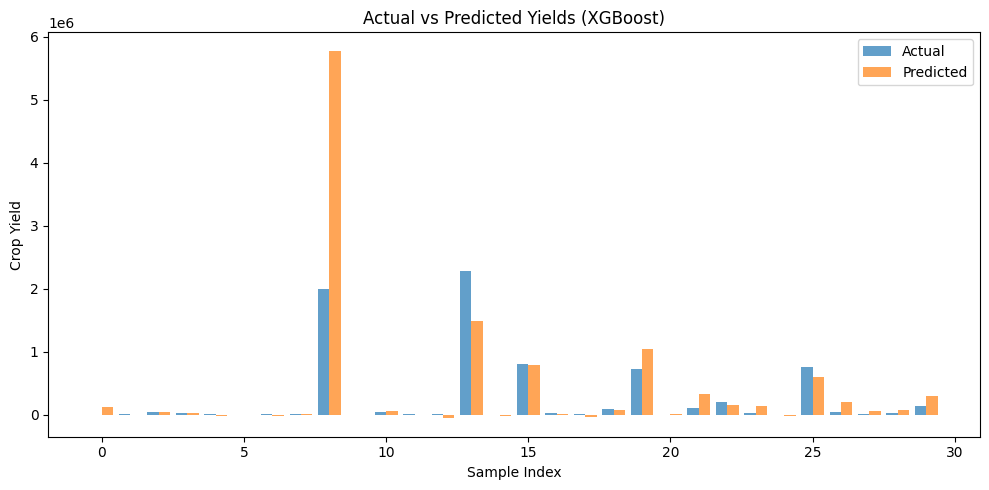

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(10, 5))
    indices = np.arange(len(y_true))
    plt.bar(indices - 0.2, y_true, width=0.4, label='Actual', alpha=0.7)
    plt.bar(indices + 0.2, y_pred, width=0.4, label='Predicted', alpha=0.7)
    plt.xlabel("Sample Index")
    plt.ylabel("Crop Yield")
    plt.title(f"Actual vs Predicted Yields ({model_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(y_test[:30], y_pred_test_rf[:30], "Random Forest")
plot_actual_vs_predicted(y_test[:30], y_pred_test_xgb[:30], "XGBoost")

In [18]:
import os

# List all files in the current directory
saved_models = [f for f in os.listdir() if f.endswith('.pkl')]
print("Saved Models:", saved_models)

Saved Models: ['best_model.pkl', 'Crop_encoder.pkl', 'crop_yield_model.pkl', 'crop_yield_rf_model.pkl', 'encoder.pkl', 'gradient_boosting_model.pkl', 'model.pkl', 'random_forest_model.pkl', 'rf_model.pkl', 'scaler.pkl', 'Season_encoder.pkl', 'State_encoder.pkl', 'xgboost_model.pkl']


In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import joblib

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

best_model = None
best_score = float('-inf')
best_model_name = ""

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    score = r2_score(y_test, predictions)
    print(f"{name} R² Score: {score:.4f}")
    
    # Check for best model
    if score > best_score:
        best_score = score
        best_model = model
        best_model_name = name

# Save the best model
joblib.dump(best_model, "best_model.pkl")
print(f"\nBest Model: {best_model_name} saved as best_model.pkl with R² Score: {best_score:.4f}")

Random Forest R² Score: 0.9941
Gradient Boosting R² Score: 0.9923
XGBoost R² Score: 0.9869

Best Model: Random Forest saved as best_model.pkl with R² Score: 0.9941


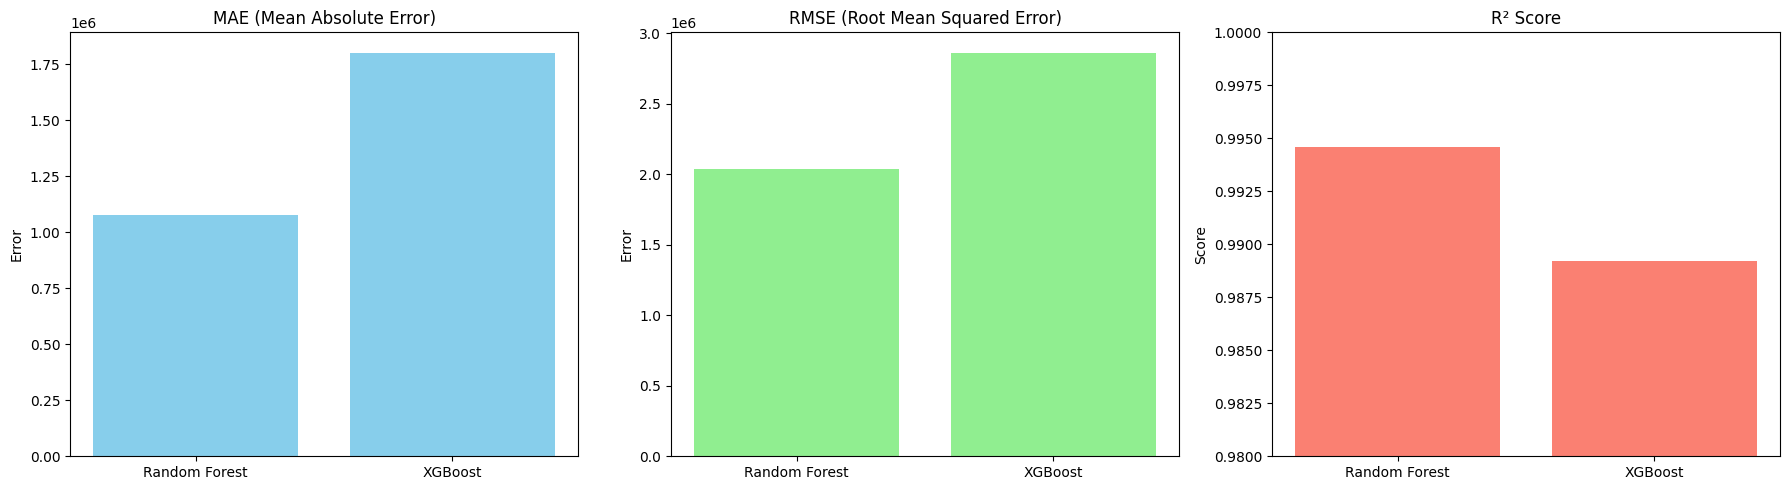

In [20]:
import matplotlib.pyplot as plt

# Actual values from your output (Testing evaluation)
mae_scores = {
    "Random Forest": 1077671.1877162318,
    "XGBoost": 1801828.875
}

rmse_scores = {
    "Random Forest": 2038408.4021086,
    "XGBoost": 2862875.758950893
}

r2_scores = {
    "Random Forest": 0.9945773188515771,
    "XGBoost": 0.9892191886901855
}

models = list(mae_scores.keys())

plt.figure(figsize=(18, 5))

# MAE
plt.subplot(1, 3, 1)
plt.bar(models, [mae_scores[m] for m in models], color='skyblue')
plt.title("MAE (Mean Absolute Error)")
plt.ylabel("Error")

# RMSE
plt.subplot(1, 3, 2)
plt.bar(models, [rmse_scores[m] for m in models], color='lightgreen')
plt.title("RMSE (Root Mean Squared Error)")
plt.ylabel("Error")

# R² Score
plt.subplot(1, 3, 3)
plt.bar(models, [r2_scores[m] for m in models], color='salmon')
plt.title("R² Score")
plt.ylabel("Score")
plt.ylim(0.98, 1.0)

plt.tight_layout()
plt.show()